### CV 노드01 퀘스트 
## <center>고양이 수염 스티커 카메라앱 만들기 </center>
----

```text
dlib을 이용하여 face detection을 하고, dlib face landmark localization을 활용하여 코 위에 수염 스티커를 합성하는 카메라앱을 직접 만든다. 

순서는 다음과 같다. 
(1) face detection 해서 얼굴 영역 찾기
(2) face landmark localization 으로 이목구비 (눈썹, 눈, 코, 입, 얼굴 윤곽 총 68 points) 찾기 
(3) 고양이 수염 스티커의 코가 올라갈 위치 계산 (인물의 코와 겹칠 수 있도록 좌표 계산) 
(4) 스티커 합성 
```
  

In [3]:
!pip install cmake opencv-python
!conda install -y dlib

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



# 라이브러리 import

In [4]:
import cv2
import dlib

print(cv2.__version__)
print(dlib.__version__)

4.13.0
20.0.0


In [5]:
import os
import matplotlib.pyplot as plt
import numpy as np
print("🌫🛸")

🌫🛸


images와 models 파일을 만들어준다.     

!mkdir -p ~/work/AIFFEL_quest_eng/03_Computer_Vision/CV01/models     
!mkdir -p ~/work/AIFFEL_quest_eng/03_Computer_Vision/CV01/images 

# 얼굴을 인식할 이미지 OpenCV로 불러오기 

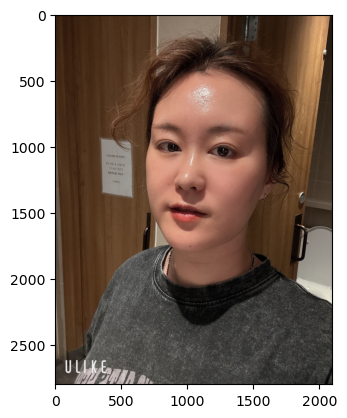

In [144]:
home_dir = os.getenv('HOME') # get environement 환경 변수 값 읽어오기 
# 이미지가 있는경로 가져오기 
my_image_path = os.path.join(home_dir, 'work/AIFFEL_quest_eng/03_Computer_Vision/CV01/images/E-9-2.png')

img_bgr = cv2.imread(my_image_path) # OpenCV로 이미지 불러오기 
img_show = img_bgr.copy() # 출력용 이미지 따로 보관

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

# 얼굴 검출

rectangles[[(617, 724) (1575, 1682)]]


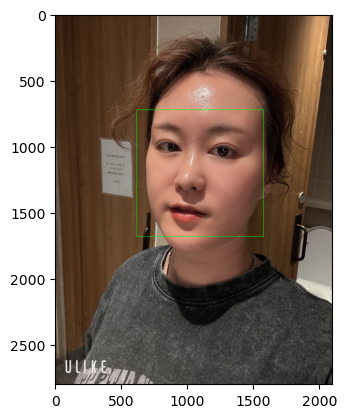

In [145]:
# detector 선언 
detector_hog = dlib.get_frontal_face_detector()  # 기본 얼굴 감지기 반환 

# detector_hog 사용하여 얼굴의 bounding box 추축
dlib_rects = detector_hog(img_rgb, 1) 
    # detector_hog(이미지객체, 이미지 피라미드 숫자) 

# 찾은 얼굴 영역 박스 리스트
print(dlib_rects)   # rectangles[[(617, 724) (1575, 1682)]]

# 찾은 얼굴 영역 좌표 
for dlib_rect in dlib_rects:
    l = dlib_rect.left()
    t = dlib_rect.top()
    r = dlib_rect.right()
    b = dlib_rect.bottom()

    # 시작점의 좌표와 종료점 좌표로 직각 사각형 그림 
	# cv2.rectangle() : drow rectangle 
	#     img_show : 1st factor. 어디에 그릴 것인가. 사각형을 그려 넣을 도화지 역할 이미지 변수 
	#     (l, t) : 사각형의 시작점(좌측 상단 x, y 좌표). 사각형 왼쪽 위 꼭지점 좌표 
	#     (r, b) : 사각형의 끝점. 사각형 오른쪽 아래 꼭지점 좌표 
	#     (0,255,0) : BGR 순서값 튜플. 사각형 선 색깔 
	#     2 : 선의 두께 Thickness
	#     lineType = cv2.LINE_AA : Anti-Aliasing(안티앨리어싱). 선을 부드럽고 깔끔하게 
    cv2.rectangle(img_show, (l,t), (r,b), (0, 255, 0), 2, lineType=cv2.LINE_AA)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()


# 얼굴의 이목구비 위치 찾기 : 얼굴 랜드마크

In [64]:
# 공개되어 있는 weight file 다운로드. bz2 압축형태이므로 입축은 풀어서 사용 
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat.bz2 ~/work/AIFFEL_quest_eng/03_Computer_Vision/CV01/models
!cd ~/work/AIFFEL_quest_eng/03_Computer_Vision/CV01 && bzip2 -d ./models/shape_predictor_68_face_landmarks.dat.bz2

6953.21s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


--2026-06-22 17:40:37--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-06-22 17:40:38--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  14.5MB/s    in 5.6s    

2026-06-22 17:40:44 (10.9 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



6965.52s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
6970.70s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


bzip2: Output file ./models/shape_predictor_68_face_landmarks.dat already exists.


In [135]:
# 저장한 landmark 모델의 주소를 model_path 변수에 저장 
model_path = os.path.join(home_dir, "work/AIFFEL_quest_eng/03_Computer_Vision/CV01/models/shape_predictor_68_face_landmarks.dat")

landmark_predictor = dlib.shape_predictor(model_path)
    # dlib 라이브러리의 shape_predictor 함수를 이용하여 모델을 불러옴
    # landmark_predictor는 RGB이미지와 dlib.rectangle를 입력 받고 dlib.full_object_detection를 반환
    # dlib.rectangle: 내부를 예측하는 박스
    # dlib.full_object_detection: 각 구성 요소의 위치와, 이미지 상의 객체의 위치를 나타냄

list_landmarks = []
    # 랜드마크의 위치를 저장할 list 생성

# 얼굴 영역 박스 마다 face landmark를 찾아서, face landmark 좌표를 저장해둔다 
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
        # 모든 landmark의 위치정보를 points 변수에 저장
    # print(points.parts())
    list_points = list(map(lambda p : (p.x, p.y), points.parts()))
        # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
        # points.parts() = points[(697, 1001), (682, 1104), ..., (927, 1499)]
        # points는 dlib.full_object_detection 의 객체. parts()함수로 개별 위치 접근 가능
        # list_points : tuple(x,y) 68개로 이루어진 리스트가 된다 
    list_landmarks.append(list_points)
        # list_landmarks에 랜드마크 리스트를 저장
        # 68개의 랜드마크가 얼굴 개수만큼 저장 

print(len(list_landmarks[0]))    # 68
    # 얼굴이 n개인 경우 list_landmarks는 n개의 원소를 갖고
    # 각 원소는 68개의 랜드마크 위치가 나열된 list
    # list_landmarks의 원소가 1개이므로 list_landmarks[1]을 호출하면 IndexError가 발생

68


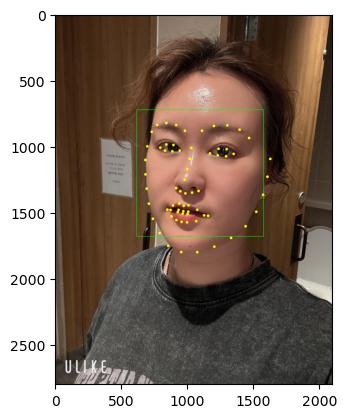

In [146]:
# 랜드 마크를 영상에 출력 

# list_landmarks의 원소가 1개이므로 아래 반복문은 한번만 실행됨
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point , 10, (0, 255, 255), -1)
            # cv2.circle: OpenCV의 원을 그리는 함수
            # img_show 이미지 위 각각의 point에
            # 크기가 10이고 (0, 255, 255)색으로 내부가 채워진(-1) 원을 그림
            # (마지막 인수가 자연수라면 그만큼의 두께의 선으로 원이 그려짐)
        
img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
    # RGB 이미지로 전환
plt.imshow(img_show_rgb)
    # 이미지를 준비
plt.show()
    # 이미지를 출력

# 스티커 적용

```text
고양이 코와 인물의 코가 겹쳐질 수 있도록 스티커를 붙이기위해서는 어디를 기준으로 해야 하는가? 
인물의 콧망울과 코를 겹치게 한다면 가장 자연스럽지 않을까? 
```

In [122]:
# dlib_rects : 얼굴 영역을 저장하고 있는 값
# dlib_rects -> rectangles[[(617, 724) (1575, 1682)]]

# list_landmarks : 68개의 랜드마크 값 저장(이목구비 위치(x,y))
# list_landmarks[0][0] = (697, 1001) ~ list_landmakrs[0][67] = (927, 1499)


# zip() : 두 그룹의 데이터를 서로 엮어주는 파이썬의 내장 함수
# dlib_rects와 list_landmarks 데이터를 엮어서, 
# 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    print(landmark[30]) 
    x = landmark[30][0] # 이미지에서 코 부위의 x값
    y = landmark[30][1] # 이미지에서 코 부위의 y값 
    w = h = dlib_rect.width()
    print (f'(x,y) : ({x},{y})')
    print (f'(w,h) : ({w},{h})')

(979, 1253)
(x,y) : (979,1253)
(w,h) : (959,959)


In [137]:
# 스티커 이미지 읽어서 적용

# 고양이 수염 이미지의 경로
sticker_path = os.path.join(home_dir, "work/AIFFEL_quest_eng/03_Computer_Vision/CV01/images/E-9-1.png")
 
img_sticker = cv2.imread(sticker_path) 
	# 스티커 이미지를 불러옵니다 
	# cv2.imread(이미지 경로) → image객체 행렬을 반환
img_sticker = cv2.resize(img_sticker, (w,h)) 
	# 스티커 이미지 조정 → w,h는 얼굴 영역의 가로를 차지하는 픽셀의 수(959)  
	# cv2.resize(image객체 행렬, (가로 길이, 세로 길이))
print (img_sticker.shape) 
	# 사이즈를 조정한 고양이 수염 
	# 출력 (959, 959, 3)

(959, 959, 3)


OpenCV에서 이미지를 합성할 때 기준이 되는 (x, y) 좌표는 이미지의 중심이 아니라 '좌측 상단(Top-Left)' 끝점이다.   
지금 코드의 (x, y)는 코의 중심점이다. 이 상태로 스티커를 붙이면 코가 고양이 수염 이미지의 '좌측 상단 끝'에 가기 때문에, 수염이 코 아래나 옆으로 삐뚤어지게 된다. 수염의 중심이 코 위치에 오게 하려면 스티커 가로/세로 길이의 절반만큼 왼쪽 위로 이동시켜야 한다.

In [138]:
# x,y,w,h 모두 위에서 반복문 안에서 지정해준 값임
# x는 이미지에서 코 부위의 x값 = 979
# y는 이미지에서 코 부위의 y값 = 1253
# w는 얼굴 영역의 가로를 차지하는 픽셀의 수 = 959
# h는 얼굴 영역의 세로를 차지하는 픽셀의 수 = 959
refined_x = x - w // 2  # 코 중심에서 스티커 가로 절반만큼 왼쪽으로
refined_y = y - h // 2  # 코 중심에서 스티커 세로 절반만큼 위쪽으로

# 원본 이미지에 스티커 이미지를 추가하기 위해서 x, y 좌표를 조정. 이미지 시작점은 top-left 좌표인 것을 감안. 
# 즉, refined_x, refined_y값에서 고양이 수염가 시작됨
print (f'(x,y) : ({refined_x},{refined_y})') 

(x,y) : (500,774)


만약 얼굴이 화면 가장자리에 너무 붙어있어 refined_x나 refined_y가 음수가 되거나 이미지 전체 해상도 크기를 넘어가면    
에러(out of bounds)가 발생한다. 따라서 안전하게 잘라주는 처리가 필요하다.

In [139]:
# 이미지를 벗어나는 예외 처리 
# 좌표 순서 (y, x, rgb channel) 
# 스티커의 좌표가 화면 밖으로 나간 경우, 
if refined_x < 0:
    img_sticker = image_stiker[:, -refined_x:]
    refined_x = 0
if refined_y < 0 : 
    img_stiker = image_stiker[-refined_y:, :]
    refined_y = 0

In [147]:
# 5. 스티커 영역만큼 원본 이미지에서 잘라내기 

# [중요] 이미지 행렬(Numpy Array)은 우리가 수학에서 쓰는 (x, y)가 아니라 (행, 열) 즉, (y, x) 순서로 접근해야 한다.
# img_show[세로_시작 : 세로_끝, 가로_시작 : 가로_끝] 형태로 슬라이싱 한다. 

# refined_y(세로 시작점)부터, refined_y에 '스티커의 세로 길이(shape[0])'를 더한 곳까지가 y축 범위
# refined_x(가로 시작점)부터, refined_x에 '스티커의 가로 길이(shape[1])'를 더한 곳까지가 x축 범위
# 이렇게 잘라낸 'sticker_area'는 원본 이미지에서 스티커가 붙을 딱 그만큼의 크기를 가진 배경 조각이 된다. 

sticker_area = img_show[
    refined_y : refined_y + img_sticker.shape[0], 
    refined_x : refined_x + img_sticker.shape[1]
]


# np.where를 활용한 투명 배경 처리 및 최종 스티커 합성 

# [문제 상황] 
# 스티커 이미지(img_sticker)는 배경이 흰색(255)이고, 진짜 수염은 검은색(0)이다. 
# 기존 코드 'np.where(img_sticker == 0, sticker_area, img_sticker)'는
# "스티커가 0(수염)인 곳을 원본 배경(sticker_area)으로 바꿔라"는 명령임.
# 결과적으로 수염이 원본 배경으로 덮어씌워져 사라지고, 흰색 상자만 남게됨. 

# [해결 방법]
# "스티커의 흰색 배경(255) 부분은 원본 얼굴을 보여주고, 흰색이 아닌 부분(수염)만 스티커 이미지를 덮어쓴다"는 연산으로 변경

# np.where(조건, 조건이 참(True)일 때 넣을 값, 조건이 거짓(False)일 때 넣을 값)
# ------------------------------------------------------------------------------
# -> 조건: img_sticker == 255 (스티커 이미지가 흰색 배경 영역인가?)
# -> 참일 때: sticker_area (흰색 배경이므로, 원본 이미지에서 미리 잘라둔 얼굴 배경 조각을 그대로 유지하여 투명하게 처리한다.)
# -> 거짓일 때: img_sticker (흰색이 아니므로, 진짜 고양이 수염 그림이 있는 부분이니 수염을 그려준다.)
# ------------------------------------------------------------------------------

img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(img_sticker == 255, sticker_area, img_sticker).astype(np.uint8)

# .astype(np.uint8)
#    np.where 연산 과정에서 데이터 타입이 변할 수 있으므로,
#    OpenCV 이미지가 표준으로 사용하는 '8비트 부호없는 정수(0~255)' 형태로 타입을 확실하게 고정해 준다. 

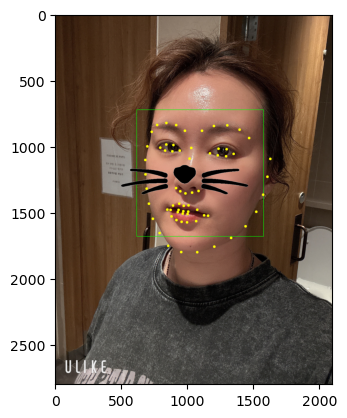

In [141]:
# 고양이 수염 스티커 적용한 이미지 보기 
# 얼굴 영역과 랜드마크를 미리 적용해놓은 img_show에 수염 스티커 적용한 이미지 출력 
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

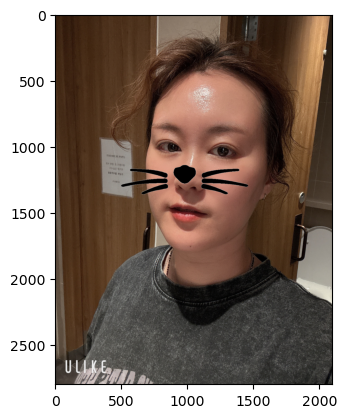

In [148]:
# bounding box와 landmark를 제거하고 최종 결과만 출력. img_bgr 활용

# 고양이 수염 이미지 
sticker_area = img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# OpenCV로 읽어온 원본 이미지에 고양이 수염 적용 
img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(img_sticker==255,sticker_area,img_sticker).astype(np.uint8)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)) 
    # bgr에서 rgb로 변환 
plt.show()

# NOTE

<b>현상:</b> 30번 랜드마크 기준 정렬로 콧망울 위치는 일치하나, 인물의 측면 회전 각도와 스티커의 정면 각도 불일치   
<b>문제점:</b> 현재 알고리즘은 2차원 평면 좌표(x, y)의 이동과 단순 크기 변화만 반영할 뿐, 얼굴의 3차원 회전에 따른 변형은 반영하지 못함.  
<b>한계점:</b> 측면을 바라보는 얼굴이나 고개를 기울인 얼굴 등의 환경에서는 스티커 앱의 사용화가 어려울 정도의 역동적 정렬 한계가 분명함.

``` text
[회고] 

30번 고유 랜드마크(코 끝)를 기준으로 좌표를 지정한 결과, 인물의 콧망울 위치에 스티커가 정확히 정렬되었다. 
그러나 인물의 얼굴이 측면으로 회전(Yaw 값의 변화)되어 있음에도 불구하고, 고양이 수염 스티커는 2차원 정면 이미지 그대로 투영되었다. 
이로 인해 인물의 얼굴 각도와 스티커의 방향성이 일치하지 않는 '시각적 이질감'이 발생하였다. 이를 해결하기 위해서는 얼굴의 회전 각도(Pose Estimation)를 산출하여 스티커 이미지에 대한 아핀 변환(Affine Transformation)이나 회전 연산이 추가로 필요함을 확인하였다."
```